# ⏱️ Time Complexity in Python: The Ultimate Masterclass

---

## 🗺️ Notebook Roadmap
```mermaid
flowchart TD
A[Introduction & Why it Matters] --> B[Theory: Measuring Efficiency]
B --> C[Formula Derivation & Simplification]
C --> D[The Complexity Decision Tree]
D --> E[Code Patterns & Examples]
E --> F[Matplotlib Growth Curves]
F --> G[Python Data Structure Complexities]
G --> H[Interview Questions & Mistakes]
H --> I[Revision Sheet & Fun Facts]
```

## 🌍 Why Does Time Complexity Matter?
Imagine you are hired to build a search feature for a library.

### Method A: Linear Search (O(n))
You walk down every single aisle, checking every book one by one.
* **10 books:** Takes 10 seconds.
* **1,000,000 books:** Takes **11.5 days**. 🐢

### Method B: Binary Search (O(log n))
The books are sorted. You walk to the middle, check if the book is in the left or right half, and discard the other half. You repeat this.
* **10 books:** Takes ~4 seconds.
* **1,000,000 books:** Takes **~20 seconds**. 🚀

> 💡 **The Insight:** Code that works perfectly for 100 users might completely crash your servers when you hit 1,000,000 users. Time Complexity predicts **scalability**, independent of your hardware.


## 📏 Theory: How Do We Measure Efficiency?

### ❌ Technique 1: Measuring Actual Time (Stopwatch)
```python
import time
start = time.time()
# run algorithm
end = time.time()
```
**Why this fails:** 
1. **Hardware Dependent:** An M3 Mac will beat a 10-year-old laptop.
2. **Background Noise:** Your OS running an antivirus scan skews the results.
3. **Not Predictive:** It tells you how fast it ran *today*, not how it will scale *tomorrow*.

### ✅ Technique 2: Counting Operations
Instead of seconds, we count **basic operations** (assignments, comparisons, math). This gives us a **machine-independent** measure of how the work grows as input size (`n`) increases.


In [2]:
# ==========================================
# ❌ PROVING WHY MEASURING TIME IS UNRELIABLE
# ==========================================

import time

def linear_search(arr, target):
    for i in range(len(arr)):
        if arr[i] == target:
            return i
    return -1

# Create array
arr = list(range(1_000_000))

# Best Case
start = time.perf_counter()
linear_search(arr, 0)
best_case = time.perf_counter() - start

# Worst Case
start = time.perf_counter()
linear_search(arr, 999_999)
worst_case = time.perf_counter() - start

ratio = worst_case / best_case if best_case > 0 else float("inf")

print(f"Best Case (First element): {best_case:.9f} seconds")
print(f"Worst Case (Last element): {worst_case:.9f} seconds")
print(f"\n⚠️ SAME algorithm, SAME array size, but {ratio:.0f}x difference in time!")
print("✅ This proves we need a theoretical measure: Big-O Notation.")

Best Case (First element): 0.000145700 seconds
Worst Case (Last element): 0.056648500 seconds

⚠️ SAME algorithm, SAME array size, but 389x difference in time!
✅ This proves we need a theoretical measure: Big-O Notation.


## 🧮 Mathematical Derivations & Big-O Rules

### Deriving O(n²) from Nested Loops
Instead of just memorizing, let's derive it mathematically.
```python
for i in range(n):       # Outer loop
    for j in range(n):   # Inner loop
        print(i, j)
```
**Step-by-step Analysis:**
1. **Outer Loop:** Runs exactly `n` times.
2. **Inner Loop:** For *every single iteration* of the outer loop, the inner loop runs `n` times.
3. **Total Operations:** 
   `n + n + n + ...` (added `n` times)
   `= n × n` 
   `= n²`
**Result:** **O(n²)**

---

## 📏 Big-O Simplification Rules
When counting operations, you get messy formulas. Apply these rules to simplify them:

1. **Drop Constants:** `O(2n)` → **O(n)**
2. **Drop Non-Dominant Terms:** `O(n² + n)` → **O(n²)**

| Exact Operations | Simplified Big-O |
| :--- | :--- |
| `5n + 10` | **O(n)** |
| `n² + 100n + 50` | **O(n²)** |
| `3n² + 4n + 10` | **O(n²)** |
```



## 🌳 The Complexity Decision Tree
When analyzing code in an interview, follow this exact decision path:

```mermaid
flowchart TD

    A["Analyze Code"]
    B{"What is the structure?"}

    A --> B

    B -->|"No loops / single statements"| C["O(1) Constant"]

    B -->|"Single Loop"| D{"How does the loop variable change?"}

    D -->|"Increases by 1"| E["O(n) Linear"]

    D -->|"Halved each iteration"| F["O(log n) Logarithmic"]

    B -->|"Nested Loops"| G{"How do the loops interact?"}

    G -->|"Inner loop runs n times"| H["O(n²) Quadratic"]

    G -->|"Inner loop processes half each time"| I["O(n log n) Linearithmic"]

    B -->|"Divide and Conquer / Efficient Sorting"| J["O(n log n) Linearithmic"]

    B -->|"Recursion with multiple branches"| K["O(2ⁿ) Exponential"]
```

In [5]:
# ==========================================
# 💻 COMMON CODING PATTERNS & COMPLEXITIES
# ==========================================

n = 5

# Pattern 1: Simple Loop -> O(n)
for i in range(n):
    print(i)

0
1
2
3
4


In [6]:
# Pattern 2: Nested Loops -> O(n²)
for i in range(n):
    for j in range(n):
        print(i, j)

0 0
0 1
0 2
0 3
0 4
1 0
1 1
1 2
1 3
1 4
2 0
2 1
2 2
2 3
2 4
3 0
3 1
3 2
3 3
3 4
4 0
4 1
4 2
4 3
4 4


In [7]:
# Pattern 3: Halving the Input -> O(log n)
while n > 1:
    n = n // 2
    print(n)

2
1


In [ ]:
# Pattern 4: Loop + Binary Search -> O(n log n)

# Binary Search Function
def binary_search(arr, target):
    low = 0
    high = len(arr) - 1
    while low <= high:
        mid = (low + high) // 2
        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    return -1


# Example Data
arr = list(range(100))
target = 75

# Number of times we want to execute binary search
iterations = len(arr)

# Pattern 4: Loop + Binary Search -> O(n log n)
# Run the binary search 'iterations' times

for _ in range(iterations):
    # Search for the target value in the sorted array
    # Binary Search Complexity: O(log n)
    result = binary_search(arr, target)

# Print the index where the target was found
print("Target found at index:", result)
print(type(n))
print(type(arr))
print(type(target))

Target found at index: 75
<class 'numpy.ndarray'>
<class 'list'>
<class 'int'>


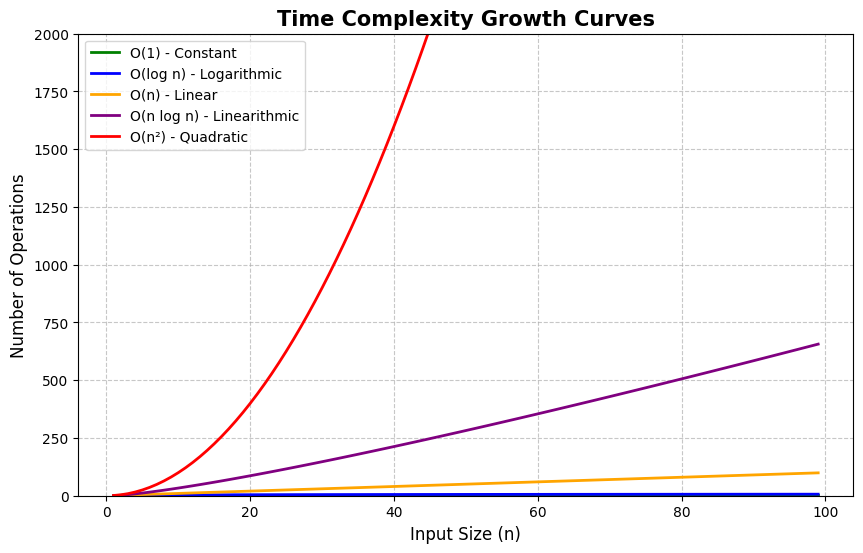

In [9]:
# ==========================================
# 📈 VISUALIZING COMPLEXITY GROWTH CURVES
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

# Define the range of n
n = np.arange(1, 100)

# Calculate complexities
o_1 = np.ones_like(n)
o_log_n = np.log2(n)
o_n = n
o_n_log_n = n * np.log2(n)
o_n2 = n**2

plt.figure(figsize=(10, 6))
plt.plot(n, o_1, label='O(1) - Constant', linewidth=2, color='green')
plt.plot(n, o_log_n, label='O(log n) - Logarithmic', linewidth=2, color='blue')
plt.plot(n, o_n, label='O(n) - Linear', linewidth=2, color='orange')
plt.plot(n, o_n_log_n, label='O(n log n) - Linearithmic', linewidth=2, color='purple')
plt.plot(n, o_n2, label='O(n²) - Quadratic', linewidth=2, color='red')

# Note: O(2^n) grows too fast to show on the same scale, 
# but imagine a curve that shoots straight up off the chart!

plt.title('Time Complexity Growth Curves', fontsize=15, fontweight='bold')
plt.xlabel('Input Size (n)', fontsize=12)
plt.ylabel('Number of Operations', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0, 2000) # Cap y-axis to keep lower complexities visible
plt.show()

## 🐍 Python Data Structure Complexities
Interviewers constantly test your knowledge of Python's internal mechanics.

| Operation | List (Dynamic Array) | Set (Hash Table) | Dict (Hash Table) |
| :--- | :--- | :--- | :--- |
| **Access / Index** | `O(1)` | `N/A` | `O(1)` avg |
| **Search (`in`)** | `O(n)` | `O(1)` avg | `O(1)` avg |
| **Insert / Append** | `O(1)`* | `O(1)` avg | `O(1)` avg |
| **Delete / Pop** | `O(n)`** | `O(1)` avg | `O(1)` avg |

*\* `list.append()` is `O(1)` **amortized** (occasionally resizes array).*
*\*\* `list.pop(0)` is `O(n)` because all elements must shift left. `list.pop()` from the end is `O(1)`.*

### 🔑 Specific Method Complexities
* `list.append(x)` → **O(1)**
* `list.pop()` → **O(1)** (from end)
* `list.pop(0)` → **O(n)** (from beginning)
* `list.insert(i, x)` → **O(n)**
* `dict.get(key)` → **O(1)** average
* `set.add(x)` → **O(1)** average
* `heapq.heappush(heap, x)` → **O(log n)**
* `heapq.heappop(heap)` → **O(log n)**

## 🎤 Master Interview Questions

### 🟢 Beginner
**Q1: What is the difference between O(n) and O(n²)?**
> **A:** O(n) means work grows linearly with input. O(n²) means work grows quadratically (usually due to nested loops). If input doubles, O(n) takes 2x longer, but O(n²) takes 4x longer.

**Q2: Why do we drop constants in Big-O?**
> **A:** Big-O describes the *growth rate* as `n` approaches infinity, not exact execution time. `O(2n)` and `O(n)` both grow linearly, so they belong to the same complexity class.

### 🟡 Intermediate
**Q3: What is the time complexity of `list.pop(0)` vs `list.pop()`?**
> **A:** `list.pop()` removes the last element, which is **O(1)**. `list.pop(0)` removes the first element, forcing Python to shift every subsequent element one position to the left, making it **O(n)**.

**Q4: Analyze this code:**
```python
for i in range(n):
    for j in range(10):
        print(i, j)
```
> **A:** The outer loop runs `n` times. The inner loop runs exactly `10` times (a constant). Total operations = `10n`. Dropping the constant, the complexity is **O(n)**.

### 🔴 Advanced
**Q5: How would you optimize a recursive Fibonacci function from O(2ⁿ) to O(n)?**
> **A:** By using **Memoization** (caching previously calculated results) or **Dynamic Programming**. This prevents recalculating the same subproblems, reducing the complexity from exponential to linear.



## ⚠️ Common Mistakes to Avoid

### Mistake 1: Confusing Sequential vs. Nested Loops
```python
# SEQUENTIAL (Add them) -> O(n) + O(n) = O(n)
for i in range(n): pass
for j in range(n): pass

# NESTED (Multiply them) -> O(n) * O(n) = O(n²)
for i in range(n):
    for j in range(n): pass
```

### Mistake 2: Ignoring Built-in Function Costs
Assuming a loop is just `O(n)`, but forgetting that `list.insert(0, x)` inside the loop is `O(n)`, making the total complexity **O(n²)**!

### Mistake 3: Keeping Lower-Order Terms
Writing `O(n² + n)` instead of simplifying it to the dominant term: **O(n²)**.


## 📋 The Ultimate Complexity Cheat Sheet

### 🏆 Hierarchy (Fastest to Slowest)
```text
⚡ O(1)       - Constant (Instant)
🚀 O(log n)   - Logarithmic (Binary Search)
🏃 O(n)       - Linear (Simple Loop)
📊 O(n log n) - Linearithmic (Merge Sort)
🐢 O(n²)      - Quadratic (Nested Loops)
🐌 O(2ⁿ)      - Exponential (Recursive Fibonacci)
💀 O(n!)      - Factorial (Traveling Salesman)
```

### 🧠 Memory Tricks
* **No loops?** → O(1)
* **Loop halves data?** → O(log n)
* **Loop touches every item?** → O(n)
* **Nested loops?** → Multiply them! O(n) × O(n) = O(n²)
* **Sorting?** → Almost always O(n log n)


## 🧠 Fun Facts

1. 🌌 **The Universe Isn't Big Enough:** An O(n!) algorithm with `n=100` would take longer than the age of the universe to compute, even if every atom in the universe was a supercomputer.
2. 📚 **Older Than Computers:** Big-O notation was invented by German mathematician Paul Bachmann in 1894 to describe mathematical series. Computer scientists borrowed it 60 years later!
3. 🔍 **The Power of Logarithms:** To find a word in a dictionary of 1,000,000 pages, Linear Search takes 1,000,000 checks. Binary Search takes only **20 checks**.
4. 🐍 **Python's Secret Weapon:** Python's built-in `sort()` uses **Timsort**, which is a hybrid of Merge Sort and Insertion Sort, guaranteeing **O(n log n)** worst-case performance.
